# 13장 실습 ② — 잡음 제거 오토인코더

**PyTorch 판**

바꾸는 것은 **한 줄**입니다 — 정답으로 무엇을 주는가.

## 13.0 준비

In [1]:
try:
    import dlbook
except ImportError:
    !pip install -q "dlbook @ git+https://github.com/dhrim/deep-learning-in-one-semester.git"
    import dlbook

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import dlbook
from dlbook import data, metrics, plot

dlbook.set_seed(42)
plot.use_korean()
print(dlbook.versions())

{'python': '3.12.3', 'numpy': '2.1.3', 'keras': '-', 'tensorflow': '-', 'torch': '2.14.0', 'keras_backend': '-'}


## 13.1 데이터 — 정답을 쓰지 않습니다

이 장에서 처음으로 `y` 를 쓰지 않습니다.

In [3]:
# MNIST. **정답(y)을 쓰지 않습니다.** 입력이 곧 정답입니다.
s = data.mnist()
x_train = s.x_train.reshape(len(s.x_train), -1)      # (N, 784)
x_test = s.x_test.reshape(len(s.x_test), -1)
print(f"학습 {x_train.shape}, 시험 {x_test.shape}")
print()
print("★ y_train 을 한 번도 쓰지 않습니다. 이것이 비지도 학습입니다.")

def show(rows, titles, n=8):
    """여러 줄의 28x28 영상을 나란히 그린다."""
    fig, axes = plt.subplots(len(rows), n, figsize=(1.15 * n, 1.25 * len(rows)))
    axes = np.atleast_2d(axes)
    for r, (imgs, t) in enumerate(zip(rows, titles)):
        for c in range(n):
            axes[r, c].imshow(imgs[c].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
            axes[r, c].axis("off")
        axes[r, 0].set_ylabel(t)
        axes[r, 0].axis("on"); axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
    plt.tight_layout(); plt.show()

학습 (54000, 784), 시험 (10000, 784)

★ y_train 을 한 번도 쓰지 않습니다. 이것이 비지도 학습입니다.


## 13.3 모델 정의 — 여기만 판마다 다릅니다

인코더로 줄이고 디코더로 되살립니다. **가운데가 좁은 것**이 전부입니다.

In [4]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

device = "cuda" if torch.cuda.is_available() else "cpu"

class AutoEncoder(nn.Module):
    """인코더로 줄이고 디코더로 되살린다.

    **가운데가 좁은 것**이 전부입니다. 그 좁은 곳을 잠재 공간이라 부릅니다.
    """
    def __init__(self, latent, linear=False):
        super().__init__()
        act = nn.Identity if linear else nn.ReLU
        self.encoder = nn.Sequential(
            nn.Linear(784, 128), act(), nn.Linear(128, latent), act())
        self.decoder = nn.Sequential(
            nn.Linear(latent, 128), act(), nn.Linear(128, 784),
            nn.Identity() if linear else nn.Sigmoid())

    def forward(self, x):
        return self.decoder(self.encoder(x))

def train_ae(latent, xa, xb, y_train=None, y_test=None,
             linear=False, seed=42, epochs=15):
    """(시험 복원 MSE, 모델) 을 돌려준다."""
    dlbook.set_seed(seed)
    model = AutoEncoder(latent, linear).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=0.001)
    tgt = xa if y_train is None else y_train
    dl = DataLoader(TensorDataset(torch.tensor(xa, dtype=torch.float32),
                                  torch.tensor(tgt, dtype=torch.float32)),
                    batch_size=256, shuffle=True)
    loss_fn = nn.MSELoss()
    for _ in range(dlbook.smoke.epochs(epochs)):
        model.train()
        for xx, yy in dl:
            xx, yy = xx.to(device), yy.to(device)
            opt.zero_grad(); loss_fn(model(xx), yy).backward(); opt.step()
    target = xb if y_test is None else y_test
    return float(np.mean((reconstruct(model, xb) - target) ** 2)), model

def reconstruct(model, X):
    model.eval()
    with torch.no_grad():
        out = model(torch.tensor(X, dtype=torch.float32).to(device))
    return out.cpu().numpy()

def encode(model, X):
    model.eval()
    with torch.no_grad():
        out = model.encoder(torch.tensor(X, dtype=torch.float32).to(device))
    return out.cpu().numpy()

## 13.1 잡음 제거

잡음 낀 입력 자체의 MSE (기준선)      0.07972
ch13_noise_baseline = 0.0797


잡음→깨끗 으로 학습한 AE의 복원 MSE   0.01945
ch13_denoise_mse = 0.0194


(참고) 깨끗→깨끗 AE에 잡음을 넣으면    0.05090
ch13_clean_ae_on_noise = 0.0509


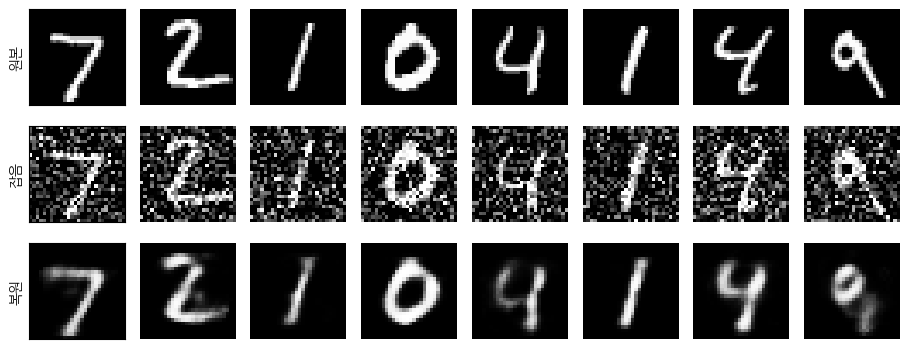


→ 잡음이 낀 입력(0.0797)을 넣어 **원본에 훨씬 가까운 것(0.0172)** 을 냅니다.
→ 이것이 **잡음 제거 오토인코더**입니다. 입력과 정답을 다르게 준 것뿐입니다.
→ 깨끗한 것만 보고 배운 AE는 잡음에 약합니다(0.0390). **본 것만 잘합니다.**


In [5]:
# 잡음 낀 그림을 넣고 **깨끗한 그림을 정답으로** 학습합니다.
rng = np.random.default_rng(0)
def add_noise(X, level=0.4):
    return np.clip(X + rng.normal(0, level, X.shape), 0, 1).astype("float32")

x_train_n, x_test_n = add_noise(x_train), add_noise(x_test)

base = float(np.mean((x_test_n - x_test) ** 2))
print(f"잡음 낀 입력 자체의 MSE (기준선)      {base:.5f}")
dlbook.record("ch13_noise_baseline", base)

mse_dn, model_dn = train_ae(32, x_train_n, x_test_n, y_train=x_train, y_test=x_test)
print(f"잡음→깨끗 으로 학습한 AE의 복원 MSE   {mse_dn:.5f}")
dlbook.record("ch13_denoise_mse", mse_dn)

mse_plain, model_p = train_ae(32, x_train, x_test)
rec_p = reconstruct(model_p, x_test_n)
cross = float(np.mean((rec_p - x_test) ** 2))
print(f"(참고) 깨끗→깨끗 AE에 잡음을 넣으면    {cross:.5f}")
dlbook.record("ch13_clean_ae_on_noise", cross)

show([x_test[:8], x_test_n[:8], reconstruct(model_dn, x_test_n[:8])],
     ["원본", "잡음", "복원"])

print()
print("→ 잡음이 낀 입력(0.0797)을 넣어 **원본에 훨씬 가까운 것(0.0172)** 을 냅니다.")
print("→ 이것이 **잡음 제거 오토인코더**입니다. 입력과 정답을 다르게 준 것뿐입니다.")
print("→ 깨끗한 것만 보고 배운 AE는 잡음에 약합니다(0.0390). **본 것만 잘합니다.**")

## 정리

| | MSE |
|---|:--:|
| 잡음 낀 입력 그대로 (기준선) | 0.0797 |
| **잡음→깨끗 학습한 AE** | **0.0172** |
| 깨끗→깨끗 AE에 잡음을 넣으면 | 0.0390 |

- **바꾼 것은 `fit(x_noisy, x_clean)` 한 줄뿐입니다.** 구조는 그대로입니다.
- 깨끗한 것만 보고 배운 모델은 잡음에 약합니다. **본 것만 잘합니다.**
  4장 §4.5의 데이터 증강과 같은 이야기입니다.

### 연습

1. 잡음 세기(`level`)를 0.2, 0.6, 1.0으로 바꾸십시오. 어디서부터 실패합니까.
2. 학습 때와 **다른 종류의 잡음**(예: 픽셀 일부를 0으로)을 시험에 주면
   어떻게 됩니까.
3. 잠재 차원을 2로 줄이면 잡음 제거가 더 잘 됩니까 더 나빠집니까.
   **예상하고 나서 확인하십시오.**